In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("./deeplearning.mplstyle")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from jupyter_utils_common import dlc
from jupyter_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [5]:
x, y = load_coffee_data()
print(x.shape, y.shape)

(200, 2) (200, 1)


KeyError: 'dldarkblue'

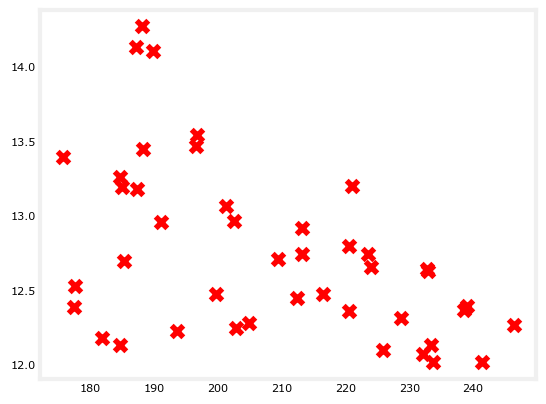

In [7]:
plt_roast(x, y)

In [8]:
print(f"Temperature Max, Min Pre-normalization: {np.max(x[:, 0]):0.2f}, {np.min(x[:, 0]):0.2f}")
print(f"Duration Max, Min Pre-normalization: {np.max(x[:, 1]):0.2f}, {np.min(x[:, 1]):0.2f}")

norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(x)
xn = norm_l(x)

print(f"Temperature Max, Min Post-normalization: {np.max(xn[:, 0]):0.2f}, {np.min(xn[:, 0]):0.2f}")
print(f"Duration Max, Min Post-normalization: {np.max(xn[:, 1]):0.2f}, {np.min(xn[:, 1]):0.2f}")

Temperature Max, Min Pre-normalization: 284.99, 151.32
Duration Max, Min Pre-normalization: 15.45, 11.51
Temperature Max, Min Post-normalization: 1.66, -1.69
Duration Max, Min Post-normalization: 1.79, -1.70


In [9]:
xt = np.tile(xn, (1000, 1))
yt = np.tile(y, (1000, 1))
print(xt.shape, yt.shape)

(200000, 2) (200000, 1)


In [11]:
tf.random.set_seed(1234)
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(3, activation="sigmoid", name="layer_1"),
        Dense(1, activation="sigmoid", name="layer_2")
    ]
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
L1_num_params = 2 * 3 + 3
L2_num_params = 3 * 1 + 1
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params)

L1 params =  9 , L2 params =  4


In [14]:
w1, b1 = model.get_layer("layer_1").get_weights()
w2, b2 = model.get_layer("layer_2").get_weights()
print(f"w1{w1.shape}:\n", w1, f"\nb1{b1.shape}:", b1)
print(f"w2{w2.shape}:\n", w2, f"\nb2{b2.shape}:", b2)

w1(2, 3):
 [[ 0.68 -1.01 -0.3 ]
 [-0.91 -0.5  -0.27]] 
b1(3,): [0. 0. 0.]
w2(3, 1):
 [[-0.33]
 [-0.3 ]
 [ 1.03]] 
b2(1,): [0.]


In [16]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
)

model.fit(
    xt, yt, epochs=10
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 267us/step - loss: 0.1869
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 263us/step - loss: 0.1286
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 256us/step - loss: 0.1159
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 252us/step - loss: 0.0425
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 252us/step - loss: 0.0168
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 255us/step - loss: 0.0110
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 245us/step - loss: 0.0077
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 250us/step - loss: 0.0055
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 247us/step - loss: 0.0040
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 248us/step - loss: 0.0029


In [17]:
w1, b1 = model.get_layer("layer_1").get_weights()
w2, b2 = model.get_layer("layer_2").get_weights()
print("w1:\n", w1, "\nb1:", b1)
print("w2:\n", w2, "\nb2:", b2)

w1:
 [[ -0.02 -10.59 -17.32]
 [ -8.58  -0.19 -14.54]] 
b1: [-10.72 -11.6   -2.58]
w2:
 [[-42.43]
 [-46.8 ]
 [ 33.39]] 
b2: [-9.09]


In [18]:
w1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]])
b1 = np.array([-9.87, -9.28, 1.01])

w2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])

model.get_layer("layer_1").set_weights([w1, b1])
model.get_layer("layer_2").set_weights([w2, b2])

In [19]:
w1, b1 = model.get_layer("layer_1").get_weights()
w2, b2 = model.get_layer("layer_2").get_weights()
print("w1:\n", w1, "\nb1:", b1)
print("w2:\n", w2, "\nb2:", b2)

w1:
 [[-8.94  0.29 12.89]
 [-0.17 -7.34 10.79]] 
b1: [-9.87 -9.28  1.01]
w2:
 [[-31.38]
 [-27.86]
 [-32.79]] 
b2: [15.54]


In [20]:
x_test = np.array([
    [200, 13.9],
    [200, 17]])

x_testn = norm_l(x_test)
predictions = model.predict(x_testn)

print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
predictions = 
 [[9.63e-01]
 [3.03e-08]]


In [21]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
        
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


In [22]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


KeyError: 'dldarkblue'

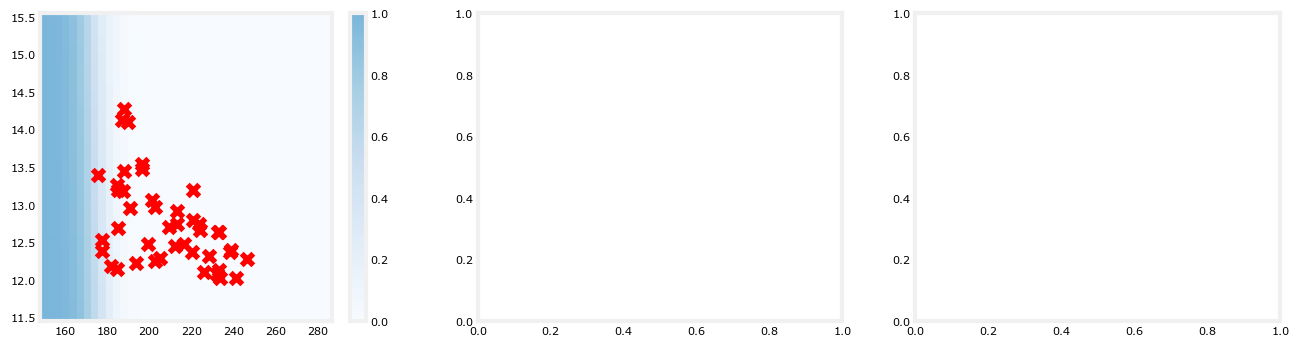

In [23]:
plt_layer(x, y.reshape(-1,), w1, b1, norm_l)

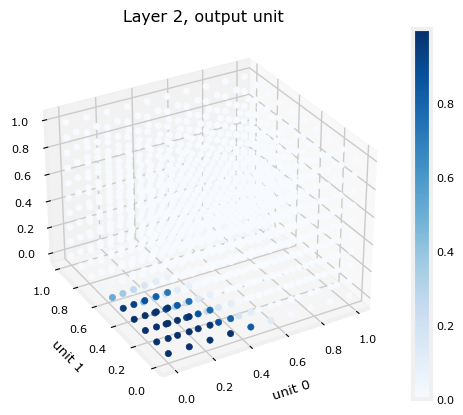

In [24]:
plt_output_unit(w2, b2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms

KeyError: 'dldarkblue'

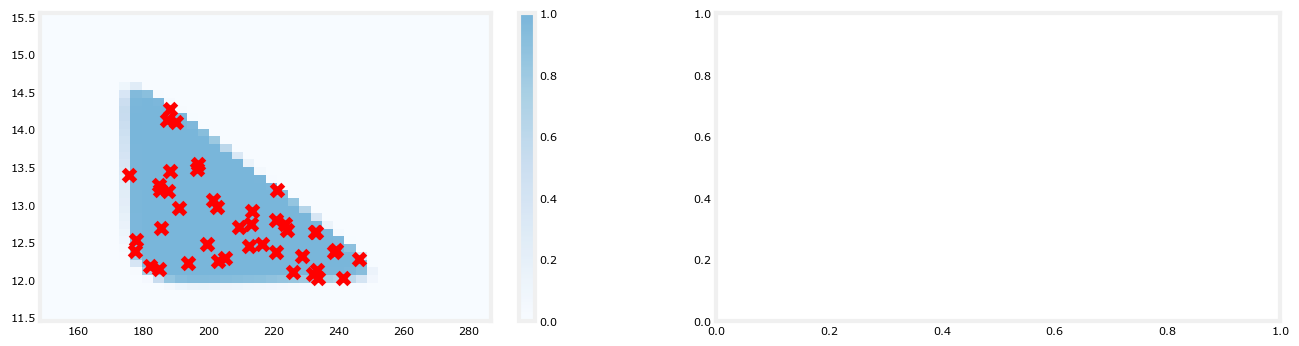

In [25]:
netf = lambda z : model.predict(norm_l(z))
plt_network(x, y, netf)